# Self-Play Diagnostics and Reviewer-Facing Evidence

This notebook loads the saved self-play results produced by `Self_Play_Experiments_v2.ipynb` and provides:

- Robustness checks (schema/shape, NaN/Inf, totals)
- Summary tables (final payoffs, convergence proxies) for **both players**
- Joint-action heatmaps for equilibrium selection analysis
- Dominant outcome identification

The intent is to give reviewers a transparent view of *what the data look like* and *why the reported figures support the claims* in the empirical chapters.

**Note**: This notebook correctly handles both symmetric games (PD, Stag Hunt, etc.) and asymmetric games (Battle of the Sexes) where P1 and P2 have different payoff structures.

---

In [1]:
# =============================================================================
# Cell 1: Library Imports and Configuration
# =============================================================================
# Core scientific stack for data analysis and visualization.

import sys
import pickle
from pathlib import Path
from typing import Dict, Any, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional seaborn for improved heatmaps
try:
    import seaborn as sns
    _HAS_SEABORN = True
except ImportError:
    _HAS_SEABORN = False

# Matplotlib configuration
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "axes.grid": True, "font.size": 11})

# Display configuration
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

print("Self-Play Diagnostics")
print("=" * 50)
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Seaborn: {'available' if _HAS_SEABORN else 'not available'}")
print("Libraries loaded.")

Self-Play Diagnostics
Python: 3.12.8
NumPy: 2.1.3
Pandas: 2.2.3
Seaborn: available
Libraries loaded.


In [2]:
# =============================================================================
# Cell 2: Load Results
# =============================================================================
# Loads the saved self-play results from the experiments notebook.
# Adjust RESULTS_PATH if your file is in a different location.

RESULTS_PATH = Path("results_artifacts/selfplay_results_latest.pkl")

if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {RESULTS_PATH.resolve()}. "
        "Run the Self-Play Experiments notebook first."
    )

with open(RESULTS_PATH, "rb") as f:
    results = pickle.load(f)

print(f"Loaded: {RESULTS_PATH}")
print(f"Created at: {results['meta']['created_at']}")
print(f"Episodes: {results['meta']['episodes']}")
print(f"Time steps: {results['meta']['time_steps']}")
print(f"Games: {results['meta']['games']}")
print(f"Policies: {list(results['meta']['policies'])}")

Loaded: results_artifacts/selfplay_results_latest.pkl
Created at: 2025-12-16T21:07:20
Episodes: 2000
Time steps: 5000
Games: ['pd', 'stag_hunt', 'battle_sexes', 'divide_cake', 'centipede']
Policies: ['epsilon_greedy', 'thompson', 'exp3']


In [3]:
# =============================================================================
# Cell 3: Data Integrity Checks
# =============================================================================
# Validates schema compliance, array shapes, and checks for numeric anomalies.

def check_integrity(results: Dict[str, Any]) -> bool:
    """Verify structural integrity of self-play results."""
    ok = True
    T = results["meta"]["time_steps"]
    
    for gk, gdata in results["games"].items():
        M = gdata["payoff_matrix"]
        n_actions = M.shape[0]
        is_symmetric = gdata.get("symmetric", True)
        
        for pk, pdata in gdata["policies"].items():
            # Check joint action counts shape
            jac = pdata["avg_joint_action_counts"]
            if jac.shape != (n_actions, n_actions):
                print(f"❌ {gk}/{pk}: joint_counts shape {jac.shape}, expected {(n_actions, n_actions)}")
                ok = False
            
            # Check joint counts sum to T
            total = float(jac.sum())
            if not np.isclose(total, T, rtol=0.01):
                print(f"⚠ {gk}/{pk}: joint_counts sum {total:.1f}, expected {T}")
            
            # Check for NaN/Inf
            for key in ["avg_payoff_p1", "avg_payoff_p2", "avg_cum_reward_p1", "avg_cum_reward_p2"]:
                arr = pdata.get(key)
                if arr is not None:
                    if np.any(np.isnan(arr)):
                        print(f"⚠ {gk}/{pk}: NaN in {key}")
                        ok = False
                    if np.any(np.isinf(arr)):
                        print(f"⚠ {gk}/{pk}: Inf in {key}")
                        ok = False
            
            # Check array lengths
            if pdata["avg_payoff_p1"].shape != (T,):
                print(f"❌ {gk}/{pk}: avg_payoff_p1 length {len(pdata['avg_payoff_p1'])}, expected {T}")
                ok = False
    
    print("✓ Integrity checks passed." if ok else "⚠ Some checks failed.")
    return ok

check_integrity(results)

✓ Integrity checks passed.


True

In [4]:
# =============================================================================
# Cell 4: Build Summary DataFrame
# =============================================================================
# Creates a tidy dataframe with final and tail-window payoffs for both players.
# Essential for asymmetric games like Battle of the Sexes.

def build_summary_df(results: Dict[str, Any], tail_window: int = 500) -> pd.DataFrame:
    """Build summary dataframe with payoff statistics for both players."""
    rows = []
    for gk, gdata in results["games"].items():
        is_symmetric = gdata.get("symmetric", True)
        for pk, pdata in gdata["policies"].items():
            p1 = pdata["avg_payoff_p1"]
            p2 = pdata["avg_payoff_p2"]
            rows.append({
                "game": gk,
                "game_label": gdata["label"],
                "policy": pk,
                "symmetric": is_symmetric,
                "final_payoff_p1": float(p1[-1]),
                "final_payoff_p2": float(p2[-1]),
                "tail_payoff_p1": float(p1[-tail_window:].mean()),
                "tail_payoff_p2": float(p2[-tail_window:].mean()),
            })
    df = pd.DataFrame(rows)
    df["payoff_gap"] = np.abs(df["final_payoff_p1"] - df["final_payoff_p2"])
    return df.sort_values(["game", "policy"]).reset_index(drop=True)

df_summary = build_summary_df(results)
print("Summary Table (both players):")
display(df_summary)

Summary Table (both players):


,game,game_label,policy,symmetric,final_payoff_p1,final_payoff_p2,tail_payoff_p1,tail_payoff_p2,payoff_gap
0,battle_sexes,Battle of the Sexes,epsilon_greedy,False,2.006383,1.986461,2.006212,1.986294,0.019921
1,battle_sexes,Battle of the Sexes,exp3,False,1.433425,1.429583,1.405470,1.401883,0.003841
2,battle_sexes,Battle of the Sexes,thompson,False,2.018553,1.962761,2.018110,1.962327,0.055792
3,centipede,Quasi-Centipede,epsilon_greedy,True,2.561134,2.604129,2.565261,2.608977,0.042995
4,centipede,Quasi-Centipede,exp3,True,2.718494,2.709581,2.751803,2.742404,0.008913
5,centipede,Quasi-Centipede,thompson,True,2.331100,2.339131,2.336720,2.344708,0.008030
6,divide_cake,Divide the Cake,epsilon_greedy,True,0.493200,0.493347,0.493073,0.493224,0.000147
7,divide_cake,Divide the Cake,exp3,True,0.441633,0.441272,0.438950,0.438585,0.000362
8,divide_cake,Divide the Cake,thompson,True,0.495968,0.500584,0.495888,0.500501,0.004616
9,pd,Prisoner's Dilemma,epsilon_greedy,True,1.072951,1.081040,1.073845,1.082163,0.008088


In [5]:
# =============================================================================
# Cell 5: Asymmetric Game Analysis
# =============================================================================
# For Battle of the Sexes, analyze which equilibrium policies select.

def analyze_asymmetric_games(results: Dict[str, Any], df: pd.DataFrame) -> None:
    """Analyze equilibrium selection in asymmetric games."""
    asymmetric_games = [gk for gk, gdata in results["games"].items() 
                        if not gdata.get("symmetric", True)]
    
    if not asymmetric_games:
        print("No asymmetric games in results.")
        return
    
    print("Asymmetric Game Analysis")
    print("=" * 60)
    
    for gk in asymmetric_games:
        gdata = results["games"][gk]
        print(f"\n{gdata['label']}:")
        print(f"  P1 prefers: {gdata['actions'][0]} (payoff {gdata['payoff_matrix'].max():.1f})")
        print(f"  P2 prefers: {gdata['actions'][1]} (payoff {gdata['payoff_matrix_p2'].max():.1f})")
        print()
        
        df_game = df[df["game"] == gk]
        for _, row in df_game.iterrows():
            # Determine which equilibrium was selected based on payoffs
            if row["final_payoff_p1"] > row["final_payoff_p2"]:
                winner = "P1's preferred"
            elif row["final_payoff_p2"] > row["final_payoff_p1"]:
                winner = "P2's preferred"
            else:
                winner = "Mixed/Equal"
            
            print(f"  {row['policy']:16s}: P1={row['final_payoff_p1']:.3f}, P2={row['final_payoff_p2']:.3f} → {winner}")

analyze_asymmetric_games(results, df_summary)

Asymmetric Game Analysis

Battle of the Sexes:
  P1 prefers: Opera (payoff 3.0)
  P2 prefers: Football (payoff 3.0)

  epsilon_greedy  : P1=2.006, P2=1.986 → P1's preferred
  exp3            : P1=1.433, P2=1.430 → P1's preferred
  thompson        : P1=2.019, P2=1.963 → P1's preferred


In [6]:
# =============================================================================
# Cell 6: Payoff Trajectory Plots
# =============================================================================
# Plots average payoff trajectories for both players across all policies.
# Uses side-by-side plots for asymmetric games.

POLICY_COLORS = {"epsilon_greedy": "C0", "thompson": "C1", "exp3": "C2"}
POLICY_LABELS = {"epsilon_greedy": "Epsilon-Greedy", "thompson": "Thompson Sampling", "exp3": "Exp3"}

def plot_payoff_trajectories(results: Dict[str, Any], game_key: str, save_path: str = None):
    """Plot payoff trajectories for both players."""
    gdata = results["games"][game_key]
    T = results["meta"]["time_steps"]
    t = np.arange(1, T + 1)
    is_symmetric = gdata.get("symmetric", True)
    
    if is_symmetric:
        # Single plot (P1 and P2 are statistically equivalent)
        fig, ax = plt.subplots(figsize=(10, 6))
        for pk, pdata in gdata["policies"].items():
            avg_payoff = (pdata["avg_payoff_p1"] + pdata["avg_payoff_p2"]) / 2
            ax.plot(t, avg_payoff, color=POLICY_COLORS.get(pk), linewidth=2,
                    label=POLICY_LABELS.get(pk, pk))
        ax.set_xlabel("Time step")
        ax.set_ylabel("Average payoff")
        ax.set_title(f"{gdata['label']}: Self-Play Payoff Trajectories")
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        # Side-by-side plots for asymmetric games
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        for pk, pdata in gdata["policies"].items():
            axes[0].plot(t, pdata["avg_payoff_p1"], color=POLICY_COLORS.get(pk), linewidth=2,
                        label=POLICY_LABELS.get(pk, pk))
            axes[1].plot(t, pdata["avg_payoff_p2"], color=POLICY_COLORS.get(pk), linewidth=2,
                        label=POLICY_LABELS.get(pk, pk))
        
        axes[0].set_xlabel("Time step")
        axes[0].set_ylabel("Average payoff")
        axes[0].set_title(f"Player 1 (prefers {gdata['actions'][0]})")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].set_xlabel("Time step")
        axes[1].set_ylabel("Average payoff")
        axes[1].set_title(f"Player 2 (prefers {gdata['actions'][1]})")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        fig.suptitle(f"{gdata['label']}: Self-Play Payoff Trajectories", fontsize=14)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

print("Payoff trajectory plotter defined.")

Payoff trajectory plotter defined.


In [7]:
# =============================================================================
# Cell 7: Joint Action Heatmap
# =============================================================================
# Visualizes joint action frequencies for equilibrium selection analysis.

def plot_joint_heatmap(results: Dict[str, Any], game_key: str, policy: str, save_path: str = None):
    """Plot joint action frequency heatmap."""
    gdata = results["games"][game_key]
    pdata = gdata["policies"][policy]
    jac = pdata["avg_joint_action_counts"]
    actions = gdata["actions"]
    
    # Normalize to frequencies
    jac_norm = jac / jac.sum() if jac.sum() > 0 else jac
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    if _HAS_SEABORN:
        sns.heatmap(jac_norm, annot=True, fmt=".2f", cbar=True, square=True,
                    xticklabels=actions, yticklabels=actions, cmap="Blues", ax=ax)
    else:
        im = ax.imshow(jac_norm, aspect="equal", cmap="Blues")
        fig.colorbar(im, ax=ax, label="Frequency")
        ax.set_xticks(range(len(actions)))
        ax.set_yticks(range(len(actions)))
        ax.set_xticklabels(actions)
        ax.set_yticklabels(actions)
        for i in range(len(actions)):
            for j in range(len(actions)):
                ax.text(j, i, f"{jac_norm[i, j]:.2f}", ha="center", va="center", fontsize=11)
    
    ax.set_xlabel("Player 2 Action")
    ax.set_ylabel("Player 1 Action")
    ax.set_title(f"{gdata['label']}: {POLICY_LABELS.get(policy, policy)}\nJoint Action Frequencies")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

print("Joint action heatmap plotter defined.")

Joint action heatmap plotter defined.


In [8]:
# =============================================================================
# Cell 8: Dominant Outcome Analysis
# =============================================================================
# Identifies the most frequent joint action for each (game, policy) pair.
# Key evidence for equilibrium selection claims.

def get_dominant_outcome(jac: np.ndarray, actions: List[str]) -> Tuple[str, str, float]:
    """Return the most frequent joint action and its share."""
    total = jac.sum()
    if total == 0:
        return ("?", "?", 0.0)
    idx = np.unravel_index(np.argmax(jac), jac.shape)
    share = float(jac[idx] / total)
    return (actions[idx[0]], actions[idx[1]], share)

def dominant_outcome_table(results: Dict[str, Any]) -> pd.DataFrame:
    """Build table of dominant outcomes for all (game, policy) pairs."""
    rows = []
    for gk, gdata in results["games"].items():
        actions = gdata["actions"]
        for pk, pdata in gdata["policies"].items():
            jac = pdata["avg_joint_action_counts"]
            a1, a2, share = get_dominant_outcome(jac, actions)
            rows.append({
                "game": gdata["label"],
                "policy": POLICY_LABELS.get(pk, pk),
                "dominant_p1": a1,
                "dominant_p2": a2,
                "share": share,
            })
    return pd.DataFrame(rows)

df_dominant = dominant_outcome_table(results)
print("Dominant Outcomes (Equilibrium Selection):")
display(df_dominant)

Dominant Outcomes (Equilibrium Selection):


,game,policy,dominant_p1,dominant_p2,share
0,Prisoner's Dilemma,Epsilon-Greedy,D,D,0.957006
1,Prisoner's Dilemma,Thompson Sampling,D,D,0.978623
2,Prisoner's Dilemma,Exp3,D,D,0.839100
3,Stag Hunt,Epsilon-Greedy,Hare,Hare,0.708236
4,Stag Hunt,Thompson Sampling,Hare,Hare,0.782202
5,Stag Hunt,Exp3,Hare,Hare,0.837670
6,Battle of the Sexes,Epsilon-Greedy,Opera,Opera,0.504086
7,Battle of the Sexes,Thompson Sampling,Opera,Opera,0.511612
8,Battle of the Sexes,Exp3,Opera,Opera,0.358836
9,Divide the Cake,Epsilon-Greedy,1/2,1/2,0.414598


In [9]:
# =============================================================================
# Cell 9: Cross-Policy Comparison
# =============================================================================
# Compares policy performance within each game.

def cross_policy_comparison(df: pd.DataFrame) -> pd.DataFrame:
    """Pivot table showing final payoffs by game and policy."""
    # Average P1 and P2 for symmetric games; keep separate for asymmetric
    df = df.copy()
    df["avg_final_payoff"] = (df["final_payoff_p1"] + df["final_payoff_p2"]) / 2
    
    pivot = df.pivot_table(
        index="game_label",
        columns="policy",
        values="avg_final_payoff",
        aggfunc="first"
    ).round(4)
    
    # Add winner column
    pivot["best_policy"] = pivot.idxmax(axis=1)
    return pivot

df_comparison = cross_policy_comparison(df_summary)
print("Cross-Policy Comparison (average of P1 & P2 final payoffs):")
display(df_comparison)

Cross-Policy Comparison (average of P1 & P2 final payoffs):


policy,epsilon_greedy,exp3,thompson,best_policy
game_label,,,,
Battle of the Sexes,1.9964,1.4315,1.9907,epsilon_greedy
Divide the Cake,0.4933,0.4415,0.4983,thompson
Prisoner's Dilemma,1.0770,1.2531,1.0332,exp3
Quasi-Centipede,2.5826,2.7140,2.3351,exp3
Stag Hunt,3.5776,2.8774,3.4253,epsilon_greedy


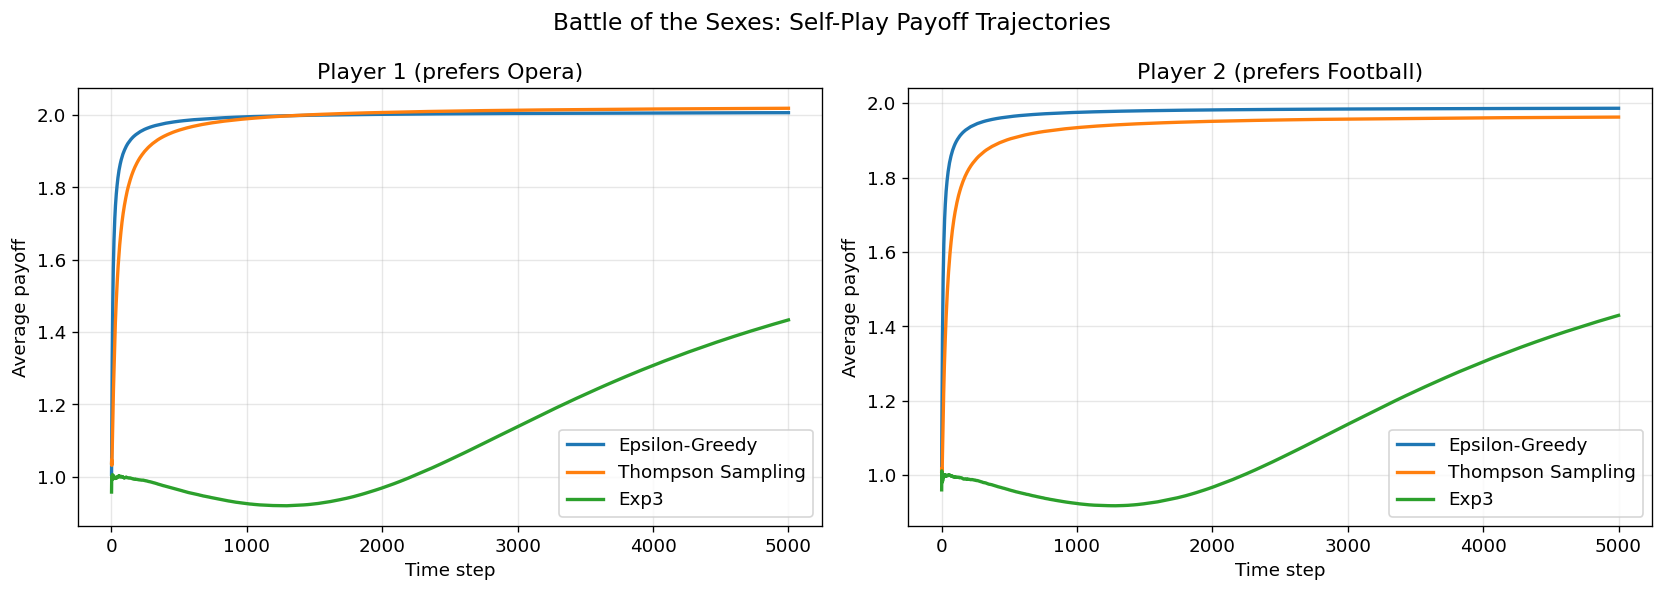

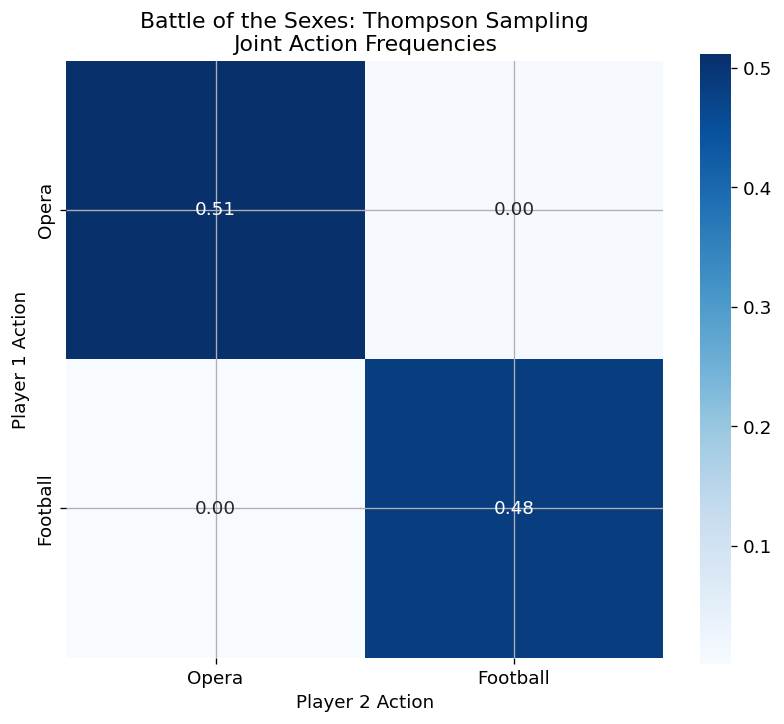

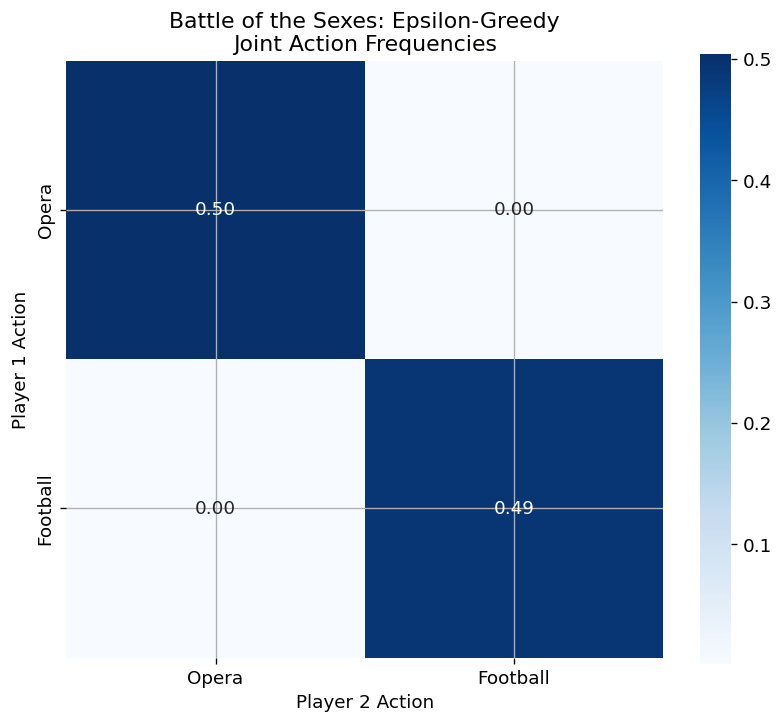

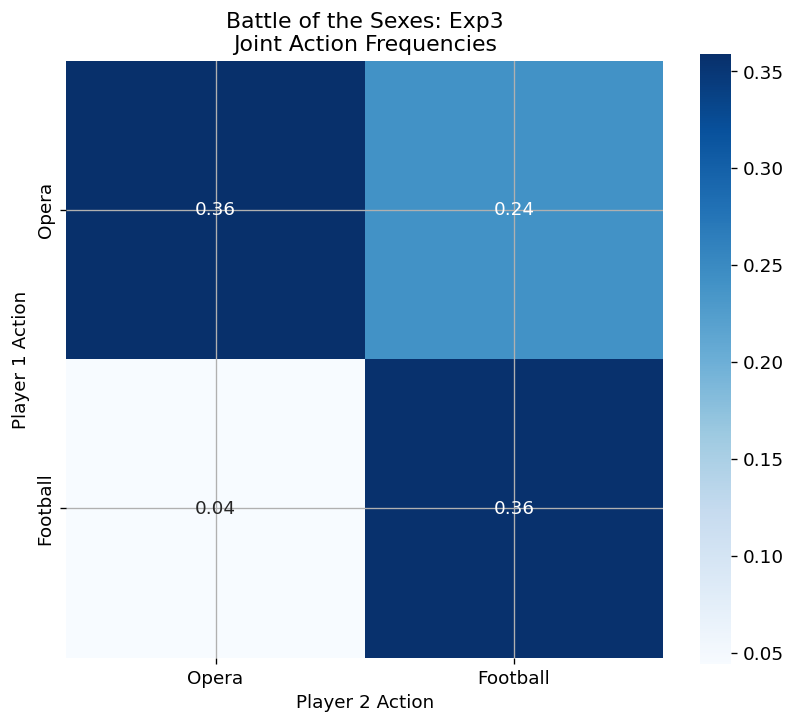

In [10]:
# =============================================================================
# Cell 10: Example - Battle of the Sexes (Asymmetric)
# =============================================================================

plot_payoff_trajectories(results, "battle_sexes")
plot_joint_heatmap(results, "battle_sexes", "thompson")
plot_joint_heatmap(results, "battle_sexes", "epsilon_greedy")
plot_joint_heatmap(results, "battle_sexes", "exp3")

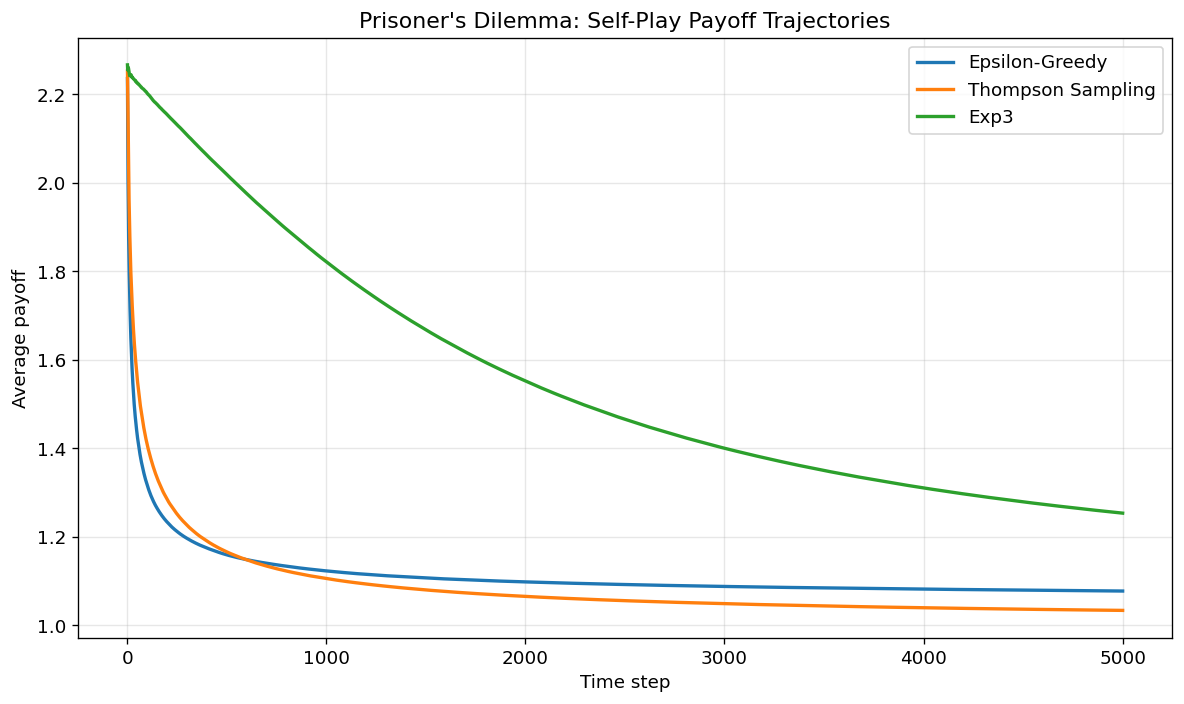

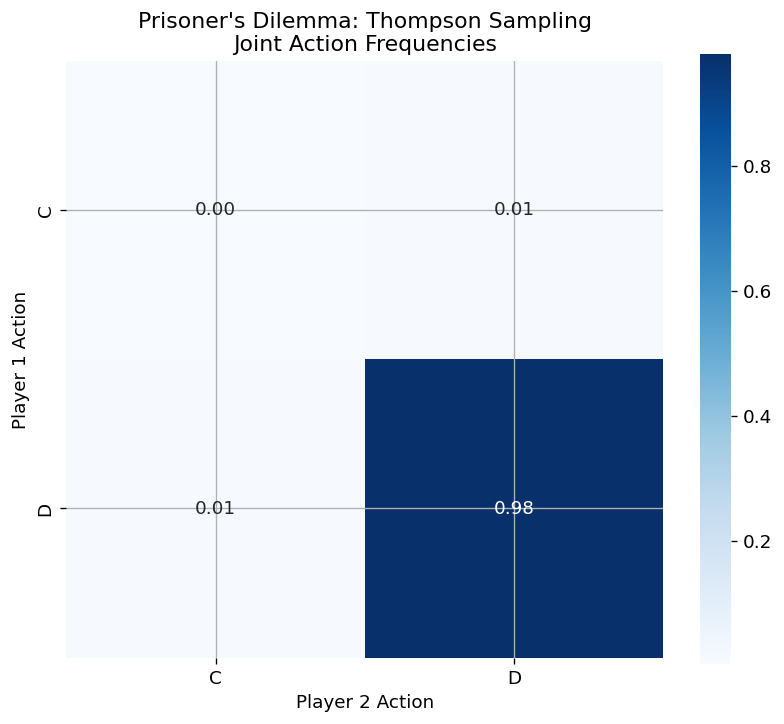

In [11]:
# =============================================================================
# Cell 11: Example - Prisoner's Dilemma (Symmetric)
# =============================================================================

plot_payoff_trajectories(results, "pd")
plot_joint_heatmap(results, "pd", "thompson")

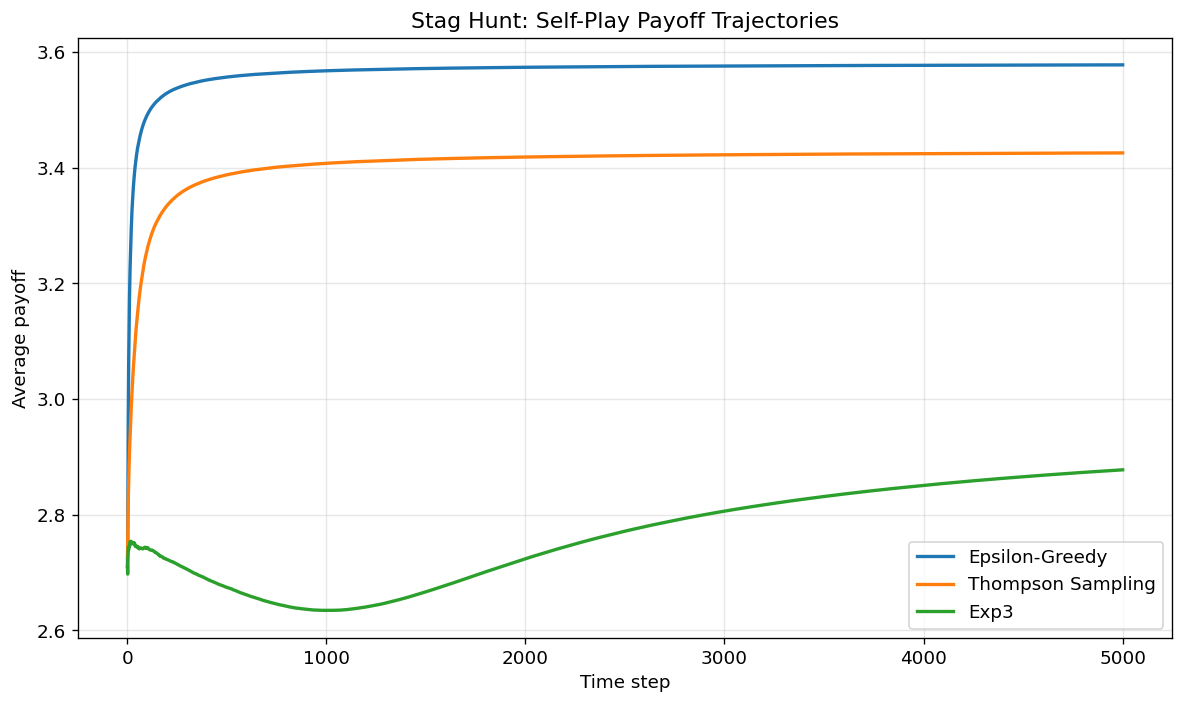

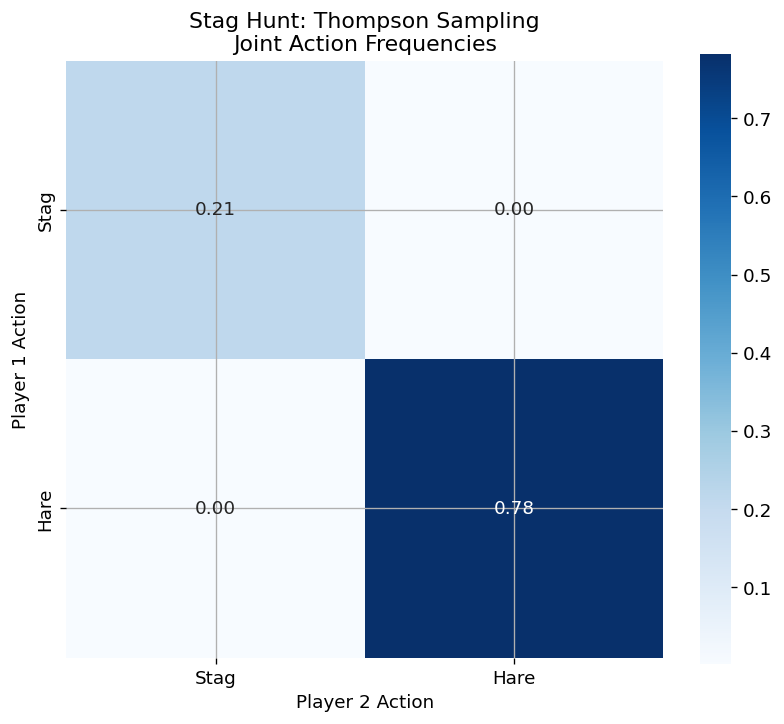

In [12]:
# =============================================================================
# Cell 12: Example - Stag Hunt (Symmetric)
# =============================================================================

plot_payoff_trajectories(results, "stag_hunt")
plot_joint_heatmap(results, "stag_hunt", "thompson")

In [13]:
# =============================================================================
# Cell 13: Export Summary Tables
# =============================================================================
# Saves summary tables as CSV for use in Chapter 7.

OUT_DIR = Path("exports")
OUT_DIR.mkdir(exist_ok=True)

df_summary.to_csv(OUT_DIR / "selfplay_summary.csv", index=False)
df_dominant.to_csv(OUT_DIR / "selfplay_dominant_outcomes.csv", index=False)
df_comparison.to_csv(OUT_DIR / "selfplay_policy_comparison.csv")

print("Exported to:", OUT_DIR.resolve())

Exported to: /Users/ashtonsperry/Documents/Lexington Books/Reinforcement Learning and Game Theory/Code and Notebooks/exports
